# Face Cutout and Chin Masking
This notebook isolates a person from the background and applies a perfectly curated, organic chin mask.

In [25]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

In [26]:
# Initialize SegFormer
print("Loading SegFormer model...")
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("SegFormer ready!")

Loading SegFormer model...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

SegFormer ready!


In [27]:
# Initialize MediaPipe Face Landmarker
print("Loading MediaPipe model...")
fm_model_path = 'face_landmarker.task'
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("MediaPipe ready!")

Loading MediaPipe model...
MediaPipe ready!


In [57]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True) # Bring to front
root.withdraw() # Hide the main tk window

file_path = filedialog.askopenfilename(
    title="Select an Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
    print("You can now run the next cell!")
else:
    print("No file selected. We will use the sample image.")


Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/pratik01/Downloads/front.png
You can now run the next cell!


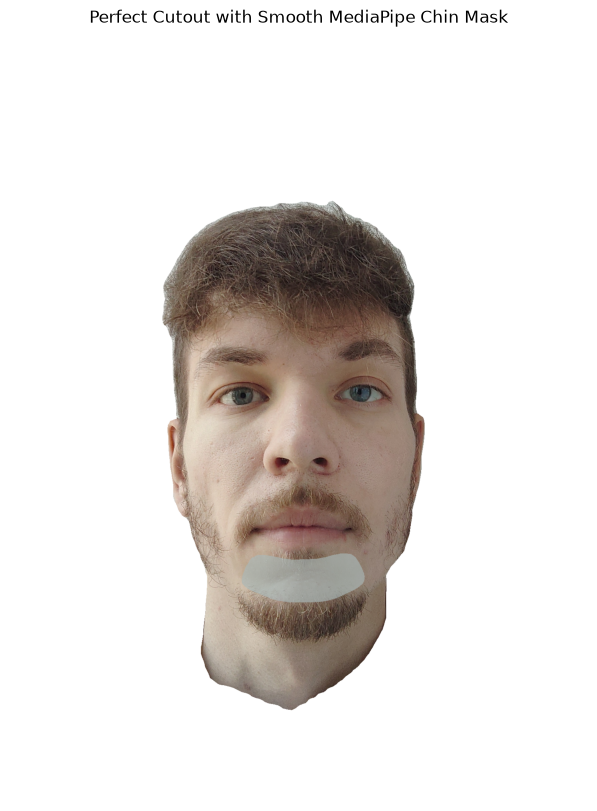

In [58]:
import os
import urllib.request

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image uploaded. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    
    # --- 1. Background Removal (SegFormer) ---
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    
    face_mask = np.isin(labels, list(range(1, 18)))
    bg_image = np.ones_like(image_rgb) * 255
    cutout_image = np.where(face_mask[..., None], image_rgb, bg_image)
    
    # --- 2. Draw Chin Overlay (MediaPipe) ---
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = landmarker.detect(mp_image)
    final_image = cutout_image.copy()
    
    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        
        # Perfect crescent shape mathematically curated from the mesh
        CHIN_INDICES = [204, 83, 18, 313, 424, 431, 395, 369, 396, 175, 171, 140, 170, 211]
        
        # Use Scipy to apply organic smoothing to the polygon
        def get_smooth_polygon(indices):
            pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in indices])
            pts = np.vstack((pts, pts[0])) # close loop
            
            tck, u = splprep([pts[:,0], pts[:,1]], s=0, per=True)
            unew = np.linspace(0, 1.0, 100)
            out = splev(unew, tck)
            
            smooth_pts = np.vstack((out[0], out[1])).T
            return np.int32(smooth_pts)

        chin_pts = get_smooth_polygon(CHIN_INDICES)
        
        overlay = final_image.copy()
        CHIN_COLOR = (170, 185, 185) # Slightly different pastel color
        
        cv2.fillPoly(overlay, [chin_pts], CHIN_COLOR)
        
        alpha = 0.65
        final_image = cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0)
    else:
        print("No face detected for landmarking.")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(final_image)
    plt.axis('off')
    plt.title("Perfect Cutout with Smooth MediaPipe Chin Mask")
    plt.show()


# Cephalometric Chin Projection Analysis
Upload a side profile image to analyze your chin's balance relative to the True Vertical Line.

# Cephalometric Chin Projection Analysis
Upload a **side profile** image (45–60° semi-profile works best with MediaPipe) to analyze your chin's projection balance.

# 🧬 Cephalometric Chin Projection Analysis
Upload a **side profile** image (45–60° semi-profile works best) to analyze how well your chin **projects** relative to your facial profile.

We use **six geometric tests** to assess chin balance:
- True Vertical Line (TVL) from Nasion
- Nasion–Pogonion facial angle
- Subnasale–Pogonion line
- Chin projection distance
- Nose-tip to chin relationship
- Lower lip to chin relationship

Opening file dialog for SIDE PROFILE image...
Please check your taskbar if the popup doesn't appear.
✅ Selected: C:/Users/pratik01/Downloads/right-45.png


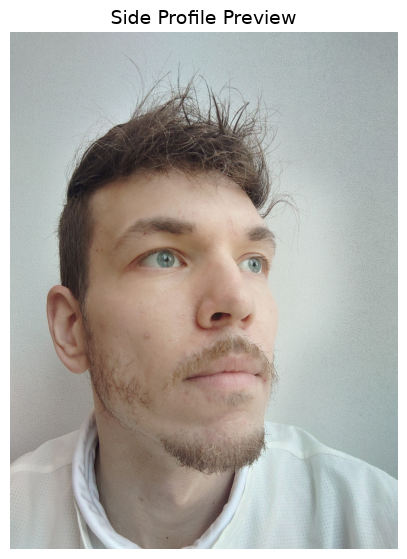

In [59]:
import tkinter as tk
from tkinter import filedialog
import cv2
import matplotlib.pyplot as plt

print("Opening file dialog for SIDE PROFILE image...")
print("Please check your taskbar if the popup doesn't appear.")

root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
side_profile_path = filedialog.askopenfilename(
    title="Select a Side Profile Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)
root.destroy()

if side_profile_path:
    print(f"✅ Selected: {side_profile_path}")
    sp_image = cv2.imread(side_profile_path)
    sp_image_rgb = cv2.cvtColor(sp_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 7))
    plt.imshow(sp_image_rgb)
    plt.axis('off')
    plt.title("Side Profile Preview", fontsize=14)
    plt.show()
else:
    print("❌ No file selected.")
    sp_image_rgb = None

In [60]:
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import math

chin_data = None  # Will hold our results

if sp_image_rgb is not None:
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        num_faces=1,
        min_face_detection_confidence=0.1,
        min_face_presence_confidence=0.1
    )

    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=sp_image_rgb)
        result = detector.detect(mp_image)

        if not result.face_landmarks:
            print("\n❌ NO FACE DETECTED!")
            print("💡 TIP: Use a 45–60° semi-profile (MediaPipe needs both eyes slightly visible).")
        else:
            lm = result.face_landmarks[0]
            sp_h, sp_w, _ = sp_image_rgb.shape

            def pt(idx):
                return np.array([lm[idx].x * sp_w, lm[idx].y * sp_h])

            # ── Extract Key Anatomical Points ──
            nasion     = pt(9)    # Bridge of nose (Nasion / Glabella)
            nose_tip   = pt(1)    # Tip of nose (Pronasale)
            subnasale  = pt(2)    # Base of nose (Subnasale)
            upper_lip  = pt(0)    # Upper lip (Labrale superius)
            lower_lip  = pt(17)   # Lower lip (Labrale inferius)
            pogonion   = pt(152)  # Chin tip (Pogonion)
            forehead   = pt(10)   # Forehead top

            # ── Determine face direction ──
            left_cheek  = pt(234)
            right_cheek = pt(454)
            is_facing_right = nose_tip[0] > (left_cheek[0] + right_cheek[0]) / 2

            # ── TRUE VERTICAL LINE (TVL) ──
            # In a standard profile photo the head is in natural position,
            # so "vertical" = straight down in the image from Nasion.
            # Chin projection = horizontal offset of Pogonion from Nasion's x.
            
            chin_horiz_offset_px = pogonion[0] - nasion[0]
            # For a LEFT-facing profile, chin BEHIND nasion means pogonion.x > nasion.x
            # For a RIGHT-facing profile, chin BEHIND nasion means pogonion.x < nasion.x
            # We want: positive = protruded, negative = retruded
            if is_facing_right:
                chin_projection_px = chin_horiz_offset_px   # forward = positive x
            else:
                chin_projection_px = -chin_horiz_offset_px  # forward = negative x, flip

            # ── Normalize by face height (forehead to chin vertical) ──
            face_height_px = abs(pogonion[1] - forehead[1])
            if face_height_px < 1:
                face_height_px = 1  # safety

            normalized_projection = chin_projection_px / face_height_px

            # ── Facial Convexity Angle (Nasion → Subnasale → Pogonion) ──
            v1 = nasion - subnasale
            v2 = pogonion - subnasale
            cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9)
            cos_angle = np.clip(cos_angle, -1, 1)
            convexity_angle = math.degrees(math.acos(cos_angle))

            # ── Nose tip to chin vertical relationship ──
            nose_chin_horiz = nose_tip[0] - pogonion[0]
            if not is_facing_right:
                nose_chin_horiz = -nose_chin_horiz

            chin_data = {
                'nasion': nasion, 'nose_tip': nose_tip, 'subnasale': subnasale,
                'upper_lip': upper_lip, 'lower_lip': lower_lip, 'pogonion': pogonion,
                'forehead': forehead, 'is_facing_right': is_facing_right,
                'chin_projection_px': chin_projection_px,
                'face_height_px': face_height_px,
                'normalized_projection': normalized_projection,
                'convexity_angle': convexity_angle,
                'nose_chin_horiz': nose_chin_horiz,
            }

            direction = "Right" if is_facing_right else "Left"
            print(f"Face Direction: {direction}")
            print(f"Chin Projection: {chin_projection_px:+.1f} px  "
                  f"(normalized: {normalized_projection:+.4f})")
            print(f"Facial Convexity Angle: {convexity_angle:.1f}°")
            print(f"  (+ve projection = protruded,  -ve = retruded)")

Face Direction: Right
Chin Projection: +56.5 px  (normalized: +0.0586)
Facial Convexity Angle: 168.8°
  (+ve projection = protruded,  -ve = retruded)


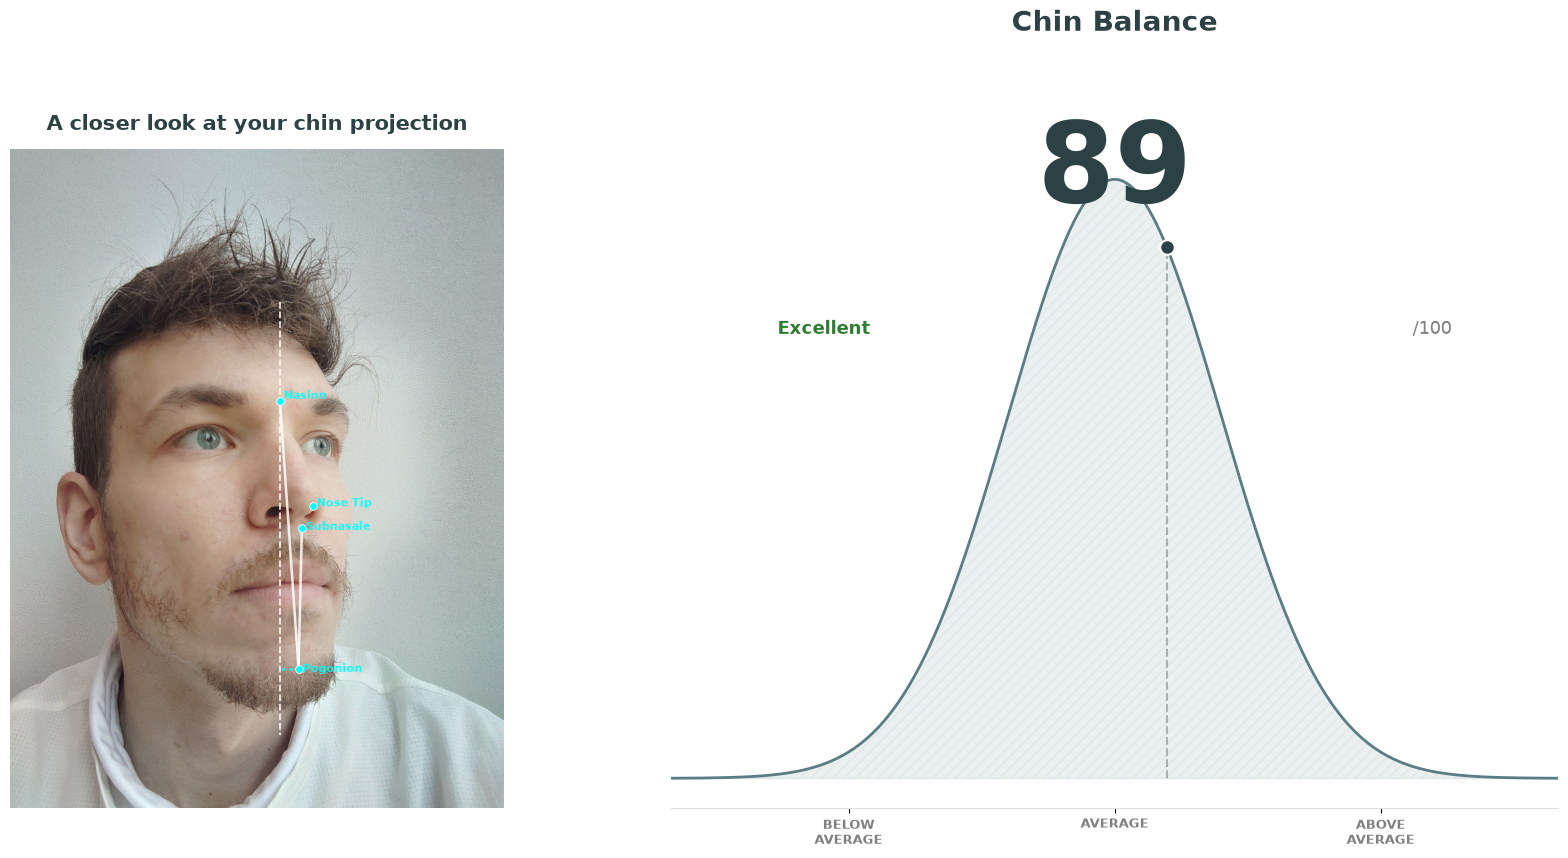


═══════════════════════════════════════════════════════
  CHIN BALANCE SCORE:  89 / 100   (Excellent)
═══════════════════════════════════════════════════════
  → Your chin is PROTRUDED relative to the True Vertical Line.
  → Facial Convexity Angle: 168.8°
  → Saved: chin_projection_analysis.png


In [61]:
import scipy.stats as stats

if chin_data is not None:
    nasion     = chin_data['nasion']
    nose_tip   = chin_data['nose_tip']
    subnasale  = chin_data['subnasale']
    upper_lip  = chin_data['upper_lip']
    lower_lip  = chin_data['lower_lip']
    pogonion   = chin_data['pogonion']
    forehead   = chin_data['forehead']
    normalized_projection = chin_data['normalized_projection']
    convexity_angle       = chin_data['convexity_angle']

    # ═══════════════════════════════════════════
    #  SCORING
    # ═══════════════════════════════════════════
    # Ideal chin sits very slightly behind nasion vertical (norm ~ -0.02 to +0.02).
    # We center the Gaussian at 0 with sigma = 0.12 so reasonable faces score well.
    ideal = 0.0
    sigma = 0.12
    z = abs(normalized_projection - ideal) / sigma
    score = int(round(100 * math.exp(-0.5 * z * z)))
    score = max(0, min(100, score))

    if score >= 80:   label, lbl_color = "Excellent",     "#2e7d32"
    elif score >= 60: label, lbl_color = "Above Average", "#558b2f"
    elif score >= 40: label, lbl_color = "Average",       "#f9a825"
    elif score >= 20: label, lbl_color = "Below Average", "#e65100"
    else:             label, lbl_color = "Poor",          "#b71c1c"

    # ═══════════════════════════════════════════
    #  FIGURE
    # ═══════════════════════════════════════════
    fig = plt.figure(figsize=(18, 9), facecolor='white')

    # ── LEFT: Annotated image ──
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(sp_image_rgb)
    ax1.axis('off')
    ax1.set_title("A closer look at your chin projection",
                  fontsize=15, fontweight='bold', color='#2c4144', pad=14)

    def draw(p1, p2, c='white', ls='-', lw=1.5, a=0.85):
        ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color=c, linestyle=ls, linewidth=lw, alpha=a)

    # True Vertical Line (dashed) from well above nasion to well below pogonion
    tvl_top    = np.array([nasion[0], nasion[1] - sp_h * 0.15])
    tvl_bottom = np.array([nasion[0], pogonion[1] + sp_h * 0.10])
    draw(tvl_top, tvl_bottom, c='white', ls='--', lw=1.3)

    # Nasion → Pogonion (main facial angle line)
    draw(nasion, pogonion, c='white', lw=1.8)

    # Subnasale → Pogonion
    draw(subnasale, pogonion, c='white', lw=1.8)

    # Horizontal projection line from pogonion to TVL
    tvl_at_chin = np.array([nasion[0], pogonion[1]])
    draw(pogonion, tvl_at_chin, c='cyan', ls=':', lw=2.0, a=0.9)

    # Landmark dots
    pts = np.array([nasion, nose_tip, subnasale, pogonion])
    ax1.scatter(pts[:, 0], pts[:, 1], color='cyan', s=30, zorder=5,
                edgecolors='white', linewidths=0.6)

    # Labels
    names   = ['Nasion', 'Nose Tip', 'Subnasale', 'Pogonion']
    offsets = [(12, -8), (12, 0), (12, 6), (12, 10)]
    for nm, p, off in zip(names, pts, offsets):
        ax1.annotate(nm, xy=p, xytext=(p[0]+off[0], p[1]+off[1]),
                     fontsize=8, color='cyan', fontweight='bold', alpha=0.9)

    # ── RIGHT: Bell-curve score ──
    ax2 = fig.add_subplot(1, 2, 2)

    x = np.linspace(-0.5, 0.5, 1000)
    y = stats.norm.pdf(x, ideal, sigma)
    ax2.plot(x, y, color='#5a7d83', linewidth=2)
    ax2.fill_between(x, y, alpha=0.12, color='#a0bec0')
    ax2.fill_between(x, y, alpha=0.06, color='#5a7d83', hatch='///')

    # User dot
    uy = stats.norm.pdf(normalized_projection, ideal, sigma)
    ax2.scatter([normalized_projection], [uy], color='#2c4144', s=110,
                zorder=5, edgecolors='white', linewidths=1.5)
    ax2.vlines(normalized_projection, 0, uy, color='#2c4144', ls='--', alpha=0.35)

    # Big score text
    ax2.text(0.5, 1.18, "Chin Balance", transform=ax2.transAxes,
             fontsize=20, ha='center', color='#2c4144', fontweight='bold')
    ax2.text(0.5, 0.92, str(score), transform=ax2.transAxes,
             fontsize=80, ha='center', color='#2c4144', fontweight='bold')
    ax2.text(0.12, 0.72, label, transform=ax2.transAxes,
             fontsize=13, ha='left', color=lbl_color, fontweight='bold')
    ax2.text(0.88, 0.72, "/100", transform=ax2.transAxes,
             fontsize=13, ha='right', color='gray')

    ax2.set_xticks([-0.3, 0.0, 0.3])
    ax2.set_xticklabels(['BELOW\nAVERAGE', 'AVERAGE', 'ABOVE\nAVERAGE'],
                        fontsize=9, fontweight='bold', color='gray')
    ax2.set_yticks([])
    for sp in ['top', 'right', 'left']:
        ax2.spines[sp].set_visible(False)
    ax2.spines['bottom'].set_color('#e0e0e0')
    ax2.set_xlim(-0.5, 0.5)

    plt.tight_layout(pad=2)
    plt.savefig('chin_projection_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"\n{'═'*55}")
    print(f"  CHIN BALANCE SCORE:  {score} / 100   ({label})")
    print(f"{'═'*55}")
    if normalized_projection > 0.05:
        print("  → Your chin is PROTRUDED relative to the True Vertical Line.")
    elif normalized_projection < -0.05:
        print("  → Your chin is RETRUDED relative to the True Vertical Line.")
    else:
        print("  → Your chin projection is WELL-BALANCED with your profile!")
    print(f"  → Facial Convexity Angle: {convexity_angle:.1f}°")
    print(f"  → Saved: chin_projection_analysis.png")
else:
    print("No chin data available. Please run the previous cells first.")

# The **proportions** of your chin
Chin height is a key dimorphic trait — a taller chin looks more **masculine**, while a shorter chin gives a softer, **feminine** look.

Upper Lip Height: 105.0 px
Chin Height:      197.4 px
Your Ratio:       1.88 : 1.00
Ideal Ratio:      1.40 : 1.00


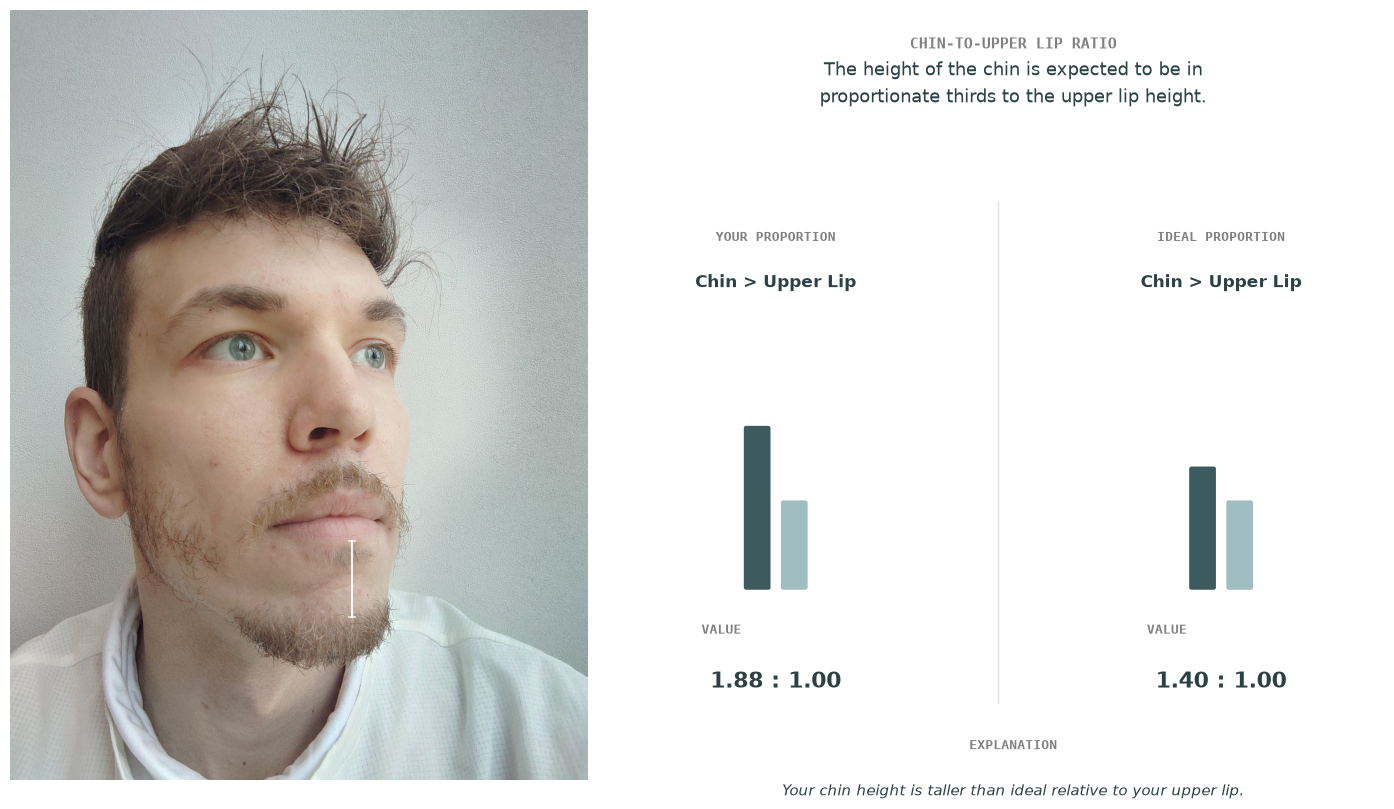


Saved: chin_proportions.png


In [62]:
# ═══════════════════════════════════════════════════════
#  CHIN-TO-UPPER LIP RATIO ANALYSIS
#  Uses the side profile image & landmarks from above
# ═══════════════════════════════════════════════════════

if chin_data is not None:
    import matplotlib.patches as mpatches
    from matplotlib.gridspec import GridSpec

    lm = None  # We need the raw landmarks again
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=sp_image_rgb)
        result = detector.detect(mp_image)
        if result.face_landmarks:
            lm = result.face_landmarks[0]

    if lm is not None:
        sp_h, sp_w, _ = sp_image_rgb.shape

        def pt(idx):
            return np.array([lm[idx].x * sp_w, lm[idx].y * sp_h])

        # ── Key points for proportions ──
        subnasale  = pt(2)    # Base of nose
        upper_lip  = pt(0)    # Upper lip vermillion border (Labrale superius)
        lower_lip  = pt(17)   # Bottom of lower lip (Labrale inferius)
        pogonion   = pt(152)  # Chin tip
        mentolabial = pt(200) # Mentolabial sulcus (fold between lip and chin)

        # ── Measurements (vertical distances in pixels) ──
        upper_lip_height = abs(subnasale[1] - upper_lip[1])
        chin_height      = abs(lower_lip[1] - pogonion[1])

        # Ratio
        if upper_lip_height > 0:
            ratio = chin_height / upper_lip_height
        else:
            ratio = 0

        ideal_ratio = 1.40  # Clinical ideal

        print(f"Upper Lip Height: {upper_lip_height:.1f} px")
        print(f"Chin Height:      {chin_height:.1f} px")
        print(f"Your Ratio:       {ratio:.2f} : 1.00")
        print(f"Ideal Ratio:      {ideal_ratio:.2f} : 1.00")

        # ═══════════════════════════════════════════
        #  RENDER
        # ═══════════════════════════════════════════
        fig = plt.figure(figsize=(18, 10), facecolor='white')
        gs = GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.05)

        # ── LEFT: Annotated face image ──
        ax1 = fig.add_subplot(gs[0])
        ax1.imshow(sp_image_rgb)
        ax1.axis('off')

        # Draw vertical measurement line from lower lip to pogonion (chin height)
        mid_x = (lower_lip[0] + pogonion[0]) / 2
        ax1.plot([mid_x, mid_x], [lower_lip[1], pogonion[1]],
                 color='white', linewidth=1.5, alpha=0.9)
        # Small horizontal ticks at endpoints
        tick_w = 8
        ax1.plot([mid_x - tick_w, mid_x + tick_w], [lower_lip[1], lower_lip[1]],
                 color='white', linewidth=1.2, alpha=0.8)
        ax1.plot([mid_x - tick_w, mid_x + tick_w], [pogonion[1], pogonion[1]],
                 color='white', linewidth=1.2, alpha=0.8)

        # Draw vertical measurement line for upper lip height
        mid_x2 = (subnasale[0] + upper_lip[0]) / 2 + 15
        ax1.plot([mid_x2, mid_x2], [subnasale[1], upper_lip[1]],
                 color='#aaaaaa', linewidth=1.2, alpha=0.7, linestyle='--')
        ax1.plot([mid_x2 - tick_w, mid_x2 + tick_w], [subnasale[1], subnasale[1]],
                 color='#aaaaaa', linewidth=1.0, alpha=0.6)
        ax1.plot([mid_x2 - tick_w, mid_x2 + tick_w], [upper_lip[1], upper_lip[1]],
                 color='#aaaaaa', linewidth=1.0, alpha=0.6)

        # ── RIGHT: Proportion comparison panel ──
        ax2 = fig.add_subplot(gs[1])
        ax2.axis('off')

        # Title
        ax2.text(0.5, 0.95, "CHIN-TO-UPPER LIP RATIO", transform=ax2.transAxes,
                 fontsize=11, ha='center', color='gray', fontweight='bold',
                 fontfamily='monospace')

        ax2.text(0.5, 0.88, "The height of the chin is expected to be in\nproportionate thirds to the upper lip height.",
                 transform=ax2.transAxes, fontsize=13, ha='center', color='#2c4144',
                 linespacing=1.5)

        # ── Bar comparison ──
        # YOUR PROPORTION (left bars)
        ax2.text(0.18, 0.70, "YOUR PROPORTION", transform=ax2.transAxes,
                 fontsize=9, ha='center', color='gray', fontweight='bold',
                 fontfamily='monospace')

        # Determine which is bigger
        if ratio >= 1.0:
            your_label = "Chin > Upper Lip"
        else:
            your_label = "Upper Lip > Chin"

        ax2.text(0.18, 0.64, your_label, transform=ax2.transAxes,
                 fontsize=12, ha='center', color='#2c4144', fontweight='bold')

        # Bars for YOUR ratio
        bar_bottom = 0.25
        bar_top = 0.58
        bar_height = bar_top - bar_bottom
        max_display = 3.0  # Fixed scale so bars don't auto-resize and look hardcoded

        # Chin bar (dark)
        chin_bar_h = bar_height * (ratio / max_display)
        rect1 = mpatches.FancyBboxPatch((0.14, bar_bottom), 0.03, chin_bar_h,
                                         boxstyle="round,pad=0.003",
                                         facecolor='#3d5a5e', edgecolor='none',
                                         transform=ax2.transAxes)
        ax2.add_patch(rect1)

        # Upper lip bar (lighter)
        lip_bar_h = bar_height * (1.0 / max_display)
        rect2 = mpatches.FancyBboxPatch((0.19, bar_bottom), 0.03, lip_bar_h,
                                         boxstyle="round,pad=0.003",
                                         facecolor='#a0bec0', edgecolor='none',
                                         transform=ax2.transAxes)
        ax2.add_patch(rect2)

        # Value label
        ax2.text(0.08, 0.19, "VALUE", transform=ax2.transAxes,
                 fontsize=9, color='gray', fontweight='bold', fontfamily='monospace')
        ax2.text(0.18, 0.12, f"{ratio:.2f} : 1.00", transform=ax2.transAxes,
                 fontsize=16, ha='center', color='#2c4144', fontweight='bold')

        # IDEAL PROPORTION (right bars)
        ax2.text(0.78, 0.70, "IDEAL PROPORTION", transform=ax2.transAxes,
                 fontsize=9, ha='center', color='gray', fontweight='bold',
                 fontfamily='monospace')
        ax2.text(0.78, 0.64, "Chin > Upper Lip", transform=ax2.transAxes,
                 fontsize=12, ha='center', color='#2c4144', fontweight='bold')

        # Ideal chin bar
        ideal_chin_h = bar_height * (ideal_ratio / max_display)
        rect3 = mpatches.FancyBboxPatch((0.74, bar_bottom), 0.03, ideal_chin_h,
                                         boxstyle="round,pad=0.003",
                                         facecolor='#3d5a5e', edgecolor='none',
                                         transform=ax2.transAxes)
        ax2.add_patch(rect3)

        # Ideal lip bar
        ideal_lip_h = bar_height * (1.0 / max_display)
        rect4 = mpatches.FancyBboxPatch((0.79, bar_bottom), 0.03, ideal_lip_h,
                                         boxstyle="round,pad=0.003",
                                         facecolor='#a0bec0', edgecolor='none',
                                         transform=ax2.transAxes)
        ax2.add_patch(rect4)

        ax2.text(0.68, 0.19, "VALUE", transform=ax2.transAxes,
                 fontsize=9, color='gray', fontweight='bold', fontfamily='monospace')
        ax2.text(0.78, 0.12, f"{ideal_ratio:.2f} : 1.00", transform=ax2.transAxes,
                 fontsize=16, ha='center', color='#2c4144', fontweight='bold')

        # Divider line between left and right
        ax2.plot([0.48, 0.48], [0.10, 0.75], transform=ax2.transAxes,
                 color='#e0e0e0', linewidth=1)

        # EXPLANATION box
        ax2.text(0.5, 0.04, "EXPLANATION", transform=ax2.transAxes,
                 fontsize=9, ha='center', color='gray', fontweight='bold',
                 fontfamily='monospace')

        diff = ratio - ideal_ratio
        if abs(diff) < 0.15:
            explanation = "Your chin-to-upper-lip ratio is close to the ideal proportion."
        elif diff < 0:
            explanation = "Your chin height is shorter than ideal relative to your upper lip."
        else:
            explanation = "Your chin height is taller than ideal relative to your upper lip."

        ax2.text(0.5, -0.02, explanation, transform=ax2.transAxes,
                 fontsize=11, ha='center', color='#2c4144', style='italic')

        plt.savefig('chin_proportions.png', dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()

        print(f"\nSaved: chin_proportions.png")
    else:
        print("Could not detect face landmarks.")
else:
    print("Please run the Chin Projection analysis cells above first.")

# Your chin **impression**
The chin shapes facial dimorphism — a smaller chin looks more **feminine**, while a broader one appears more **masculine**.

Opening file dialog for FRONT-FACING image... Please check your taskbar.
✅ Selected: C:/Users/pratik01/Downloads/front.png
Jaw-to-Cheek Ratio (Masculinity): 0.975
Norm Chin Height (Robustness):    0.126
Grid Plotted: X=8, Y=8


C:\Users\pratik01\AppData\Local\Temp\ipykernel_4428\3670208674.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


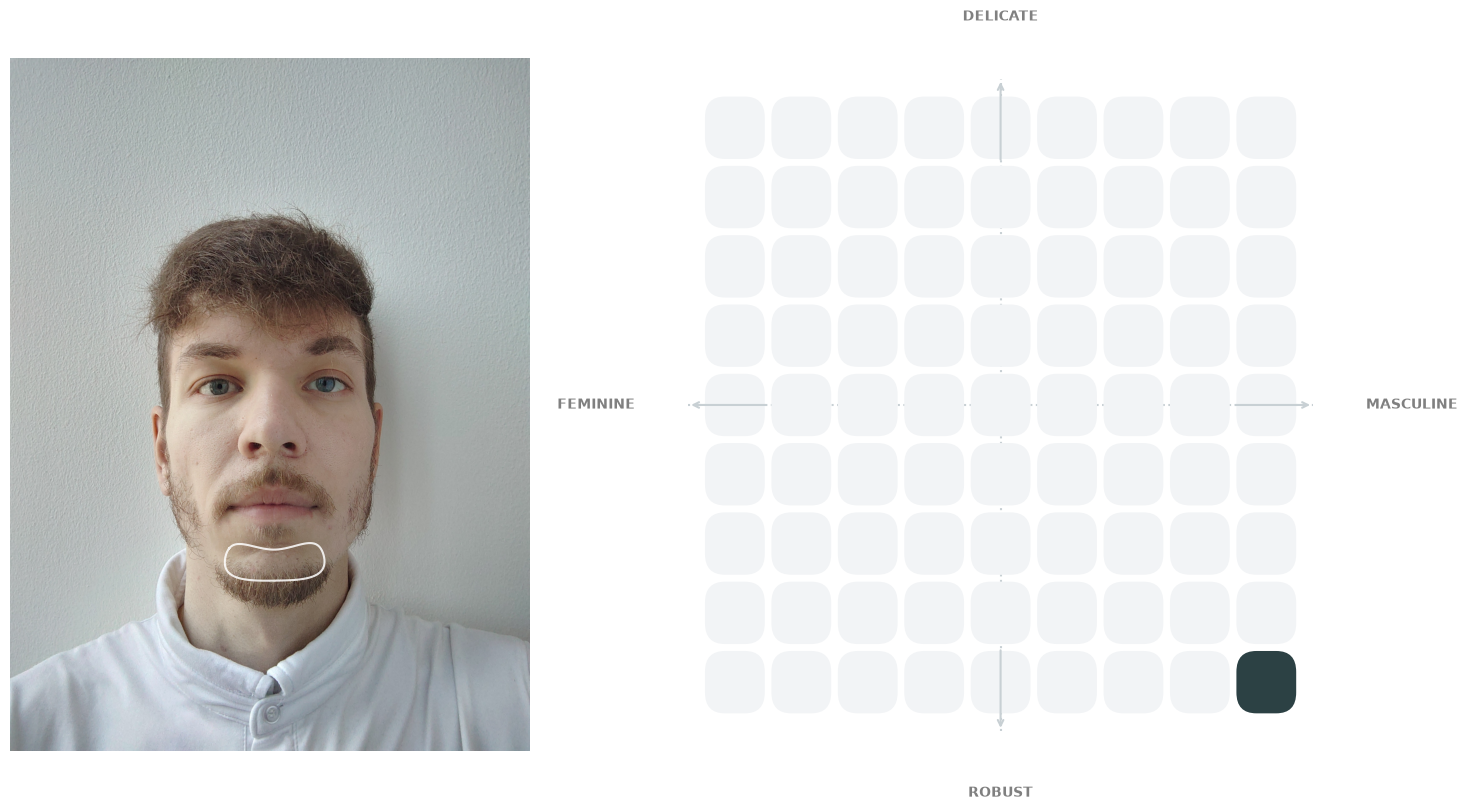

In [63]:
# ═══════════════════════════════════════════════════════
#  CHIN IMPRESSION (DIMORPHISM) ANALYSIS
# ═══════════════════════════════════════════════════════
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.interpolate import splprep, splev

print("Opening file dialog for FRONT-FACING image... Please check your taskbar.")
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
front_path = filedialog.askopenfilename(
    title="Select a Front-Facing Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)
root.destroy()

if front_path:
    print(f"✅ Selected: {front_path}")
    front_img = cv2.imread(front_path)
    front_img = cv2.cvtColor(front_img, cv2.COLOR_BGR2RGB)
    
    base_options = mp_python.BaseOptions(model_asset_path='face_landmarker.task')
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        min_face_detection_confidence=0.1, min_face_presence_confidence=0.1
    )
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=front_img)
        res = detector.detect(mp_img)
        
        if res.face_landmarks:
            lm = res.face_landmarks[0]
            h, w, _ = front_img.shape
            
            def pt(idx):
                return np.array([lm[idx].x * w, lm[idx].y * h])
            
            # ── 1. Geometric Extraction (Advanced Dimorphism) ──
            # Face Width (Bizygomatic - cheekbones)
            face_width = np.linalg.norm(pt(234) - pt(454))
            # Face Height (Forehead to Chin)
            face_height = np.linalg.norm(pt(10) - pt(152))
            
            # Jaw Width (Bigonial - outer jaw angles 132 and 361)
            jaw_width = np.linalg.norm(pt(132) - pt(361))
            
            # Chin Height (Mentolabial sulcus 200 to Pogonion 152)
            chin_height_real = np.linalg.norm(pt(200) - pt(152))
            
            # ── 2. Dimorphism Scoring Logic ──
            # X-Axis: Feminine (Narrow/V-Shape) to Masculine (Wide/Square)
            # We use the Jaw-to-Cheek ratio. 
            # Females typically ~0.75 (tapered), Males typically ~0.90+ (square)
            jaw_cheek_ratio = jaw_width / face_width
            
            grid_x_float = (jaw_cheek_ratio - 0.73) / (0.90 - 0.73) * 8
            grid_x = int(np.clip(round(grid_x_float), 0, 8))
            
            # Y-Axis: Delicate (Short) to Robust (Tall)
            # We use Chin Height / Face Height
            # Females typically have a vertically shorter chin button (~0.05 to 0.08)
            # Males have a taller, more robust chin button (~0.09 to 0.12+)
            norm_chin_height = chin_height_real / face_height
            
            grid_y_float = (norm_chin_height - 0.05) / (0.11 - 0.05) * 8
            grid_y = int(np.clip(round(grid_y_float), 0, 8))
            
            print(f"Jaw-to-Cheek Ratio (Masculinity): {jaw_cheek_ratio:.3f}")
            print(f"Norm Chin Height (Robustness):    {norm_chin_height:.3f}")
            print(f"Grid Plotted: X={grid_x}, Y={grid_y}")
            
            # ── 3. Render ──
            fig = plt.figure(figsize=(18, 9), facecolor='white')
            gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.1)
            
            # LEFT: Image with chin outline
            ax1 = fig.add_subplot(gs[0])
            ax1.imshow(front_img)
            ax1.axis('off')
            
            # ── mathematically perfect synthetic shield overlay ──
            top_center = pt(200)
            bottom_center = pt(152)
            
            # Dimensions
            c_height = np.linalg.norm(bottom_center - top_center)
            c_width = np.linalg.norm(pt(149) - pt(378)) * 0.95
            
            # Face angle
            vec = bottom_center - top_center
            angle = np.arctan2(vec[1], vec[0]) - np.pi/2
            
            center_pt = (top_center + bottom_center) / 2
            
            # Synthetic points for a perfect shield (local coords)
            synth_pts = [
                (-c_width/2.2, -c_height/2.2), # Top Left
                (0, -c_height/2.5),            # Top Center (slight dip)
                (c_width/2.2, -c_height/2.2),  # Top Right
                (c_width/2, 0),                # Right edge
                (0, c_height/2),               # Bottom tip
                (-c_width/2, 0)                # Left edge
            ]
            
            # Rotate and translate
            cos_a = np.cos(angle)
            sin_a = np.sin(angle)
            rot_mat = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
            
            rotated_pts = []
            for p in synth_pts:
                rp = np.dot(rot_mat, np.array(p))
                rotated_pts.append((rp[0] + center_pt[0], rp[1] + center_pt[1]))
                
            pts = np.array(rotated_pts)
            pts = np.vstack((pts, pts[0])) # close loop
            
            from scipy.interpolate import splprep, splev
            tck, u = splprep([pts[:, 0], pts[:, 1]], s=0, per=True)
            unew = np.linspace(0, 1, 100)
            out = splev(unew, tck)
            
            ax1.plot(out[0], out[1], color='white', linewidth=1.5, alpha=0.85)
            
            # RIGHT: 9x9 Dimorphism Matrix
            ax2 = fig.add_subplot(gs[1])
            ax2.axis('off')
            
            for i in range(9):
                for j in range(9):
                    x_pos = i + 1
                    y_pos = 9 - j
                    
                    is_target = (i == grid_x and j == grid_y)
                    color = '#2c4144' if is_target else '#f2f4f6'
                    
                    rect = mpatches.FancyBboxPatch(
                        (x_pos - 0.35, y_pos - 0.35), 0.7, 0.7,
                        boxstyle="round,pad=0.1,rounding_size=0.3",
                        facecolor=color, edgecolor='none'
                    )
                    ax2.add_patch(rect)
                    
            ax2.set_xlim(0, 10)
            ax2.set_ylim(0, 10)
            
            ax2.plot([0.3, 9.7], [5, 5], color='#c8d0d4', linestyle=':', linewidth=1.5, zorder=0)
            ax2.plot([5, 5], [0.3, 9.7], color='#c8d0d4', linestyle=':', linewidth=1.5, zorder=0)
            
            arrow_style = dict(arrowstyle='->', color='#c8d0d4', lw=1.5)
            ax2.annotate('', xy=(9.7, 5), xytext=(8.5, 5), arrowprops=arrow_style)
            ax2.annotate('', xy=(0.3, 5), xytext=(1.5, 5), arrowprops=arrow_style)
            ax2.annotate('', xy=(5, 9.7), xytext=(5, 8.5), arrowprops=arrow_style)
            ax2.annotate('', xy=(5, 0.3), xytext=(5, 1.5), arrowprops=arrow_style)
            
            font_props = dict(fontsize=10, color='gray', fontweight='bold', fontfamily='sans-serif')
            ax2.text(-0.5, 5, "FEMININE", va='center', ha='right', **font_props)
            ax2.text(10.5, 5, "MASCULINE", va='center', ha='left', **font_props)
            ax2.text(5, 10.5, "DELICATE", va='bottom', ha='center', **font_props)
            ax2.text(5, -0.5, "ROBUST", va='top', ha='center', **font_props)
            
            plt.tight_layout()
            plt.savefig('chin_impression.png', dpi=150, bbox_inches='tight', facecolor='white')
            plt.show()
            
        else:
            print("Could not detect face landmarks in the front image.")
else:
    print("No image selected.")